In [ ]:
# Author: Jay Annadurai
# Class: B585 - Biomedical Analytics
# Date: 8 Dec 2025
# Desc: Q2 DHIS2

In [ ]:
# JayCoLab (JCL) — Minimal Module of Utility Functions

JCL <- local({

  # Goal: Ensure one or more packages are available
  # Install if not available, use if available
  use_package <- function(pkgs, quietly = TRUE, attach = TRUE) {

    # Normalize input
    pkgs <- as.character(pkgs)

    # Ensure CRAN repo is configured
    repos <- getOption("repos")
    if (is.null(repos) || is.na(repos["CRAN"]) || repos["CRAN"] == "@CRAN@") {
      options(repos = c(CRAN = "https://cloud.r-project.org"))
    }

    # Install missing packages
    missing <- setdiff(pkgs, rownames(installed.packages()))
    if (length(missing)) install.packages(missing)

    # 4) Optionally attach packages; always verify availability
    availability <- vapply(pkgs, function(p) {
      ok <- requireNamespace(p, quietly = quietly)
      if (attach && ok) {
        suppressPackageStartupMessages(library(p, character.only = TRUE))
      }
      ok
    }, logical(1), USE.NAMES = TRUE)

    invisible(availability)
  }

  # Expose public API
  # Functions here are the ones available globally
  list(
    use_package = use_package,
    use_pkg = use_package
  )
})

# Module Alias
JayCoLab <- JCL

# --- Examples ---------------------------------------------------------------
# JCL$use_package("forecast")                 # install if needed, then attach
# JCL$use_package(c("forecast","MLmetrics"))  # can check packages in parallel

In [ ]:
# Load required libraries
# library(tidyverse)    # Data manipulation and visualization
# library(lubridate)    # Date handling
# library(forecast)     # Time series forecasting
# library(tseries)      # Time series tests
# library(zoo)          # Time series objects
# library(forecast)     # Generate Forecasts
# library(MLmetrics)    # Evaluate Forecasting Models
# library(ggplot2)       # Plot Analysis

# Install the Libraries
JCL$use_package(c("tidyverse","ggplot2","lubridate","forecast","tseries","zoo","forecast","MLmetrics"))

In [ ]:
# Read data
rhrr_data <- read.csv("Q2-Reproductive-Health-Reporting-Rate-Sierra-Leone-By-District-Jan-2024-to-Jun-2025.csv")

# View structure
str(rhrr_data)
head(rhrr_data)

'data.frame':	18 obs. of  21 variables:
 $ dataid           : chr  "QX4ZTUbOt3a.REPORTING_RATE" "QX4ZTUbOt3a.REPORTING_RATE" "QX4ZTUbOt3a.REPORTING_RATE" "QX4ZTUbOt3a.REPORTING_RATE" ...
 $ dataname         : chr  "Reproductive Health - Reporting rate" "Reproductive Health - Reporting rate" "Reproductive Health - Reporting rate" "Reproductive Health - Reporting rate" ...
 $ datacode         : logi  NA NA NA NA NA NA ...
 $ datadescription  : logi  NA NA NA NA NA NA ...
 $ periodid         : int  202401 202402 202403 202404 202405 202406 202407 202408 202409 202410 ...
 $ periodname       : chr  "January 2024" "February 2024" "March 2024" "April 2024" ...
 $ periodcode       : int  202401 202402 202403 202404 202405 202406 202407 202408 202409 202410 ...
 $ perioddescription: logi  NA NA NA NA NA NA ...
 $ Bo               : num  77 77 78.6 80.2 81 ...
 $ Bombali          : num  94.8 97.9 100 99 96.9 ...
 $ Bonthe           : num  65.4 59.6 71.2 65.4 75 ...
 $ Kailahun         : num  92

,dataid,dataname,datacode,datadescription,periodid,periodname,periodcode,perioddescription,Bo,Bombali,⋯,Kailahun,Kambia,Kenema,Koinadugu,Kono,Moyamba,Port.Loko,Pujehun,Tonkolili,Western.Area
,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,<int>,<lgl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202401,January 2024,202401,NA,76.98,94.79,⋯,92.21,87.10,89.34,74.29,40.00,96.81,88.07,86.15,78.49,79.81
2,QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202402,February 2024,202402,NA,76.98,97.92,⋯,94.81,80.65,90.98,65.71,76.47,94.68,88.07,86.15,87.10,80.77
3,QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202403,March 2024,202403,NA,78.57,100.00,⋯,96.10,93.55,95.90,70.00,84.71,97.87,88.99,93.85,90.32,90.38
4,QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202404,April 2024,202404,NA,80.16,98.96,⋯,93.51,93.55,95.90,74.29,84.71,97.87,88.99,89.23,89.25,86.54
5,QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202405,May 2024,202405,NA,80.95,96.88,⋯,94.81,83.87,95.90,70.00,64.71,95.74,88.99,93.85,91.40,83.65
6,QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202406,June 2024,202406,NA,81.75,98.96,⋯,96.10,93.55,94.26,70.00,84.71,95.74,90.83,95.38,91.40,85.58


In [ ]:
# Extract district columns (columns 9-21)
districts <- colnames(rhrr_data)[9:21]
print(paste("Number of districts:", length(districts)))
print(districts)

[1] "Number of districts: 13"
 [1] "Bo"           "Bombali"      "Bonthe"       "Kailahun"     "Kambia"      
 [6] "Kenema"       "Koinadugu"    "Kono"         "Moyamba"      "Port.Loko"   
[11] "Pujehun"      "Tonkolili"    "Western.Area"


In [ ]:
# Extract Date components (Year, Month, Date) from rhrr_data
rhrr_data <- rhrr_data %>%
  mutate(
    Year = as.integer(substr(periodcode, 1, 4)),
    Month = as.integer(substr(periodcode, 5, 6)),
    Date = ymd(paste(Year, Month, "01", sep = "-"))
  )

rhrr_data

dataid,dataname,datacode,datadescription,periodid,periodname,periodcode,perioddescription,Bo,Bombali,⋯,Koinadugu,Kono,Moyamba,Port.Loko,Pujehun,Tonkolili,Western.Area,Year,Month,Date
<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,<int>,<lgl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<date>
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202401,January 2024,202401,NA,76.98,94.79,⋯,74.29,40.00,96.81,88.07,86.15,78.49,79.81,2024,1,2024-01-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202402,February 2024,202402,NA,76.98,97.92,⋯,65.71,76.47,94.68,88.07,86.15,87.10,80.77,2024,2,2024-02-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202403,March 2024,202403,NA,78.57,100.00,⋯,70.00,84.71,97.87,88.99,93.85,90.32,90.38,2024,3,2024-03-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202404,April 2024,202404,NA,80.16,98.96,⋯,74.29,84.71,97.87,88.99,89.23,89.25,86.54,2024,4,2024-04-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202405,May 2024,202405,NA,80.95,96.88,⋯,70.00,64.71,95.74,88.99,93.85,91.40,83.65,2024,5,2024-05-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202406,June 2024,202406,NA,81.75,98.96,⋯,70.00,84.71,95.74,90.83,95.38,91.40,85.58,2024,6,2024-06-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202407,July 2024,202407,NA,84.92,100.00,⋯,77.14,82.35,96.81,90.83,93.85,88.17,85.58,2024,7,2024-07-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202408,August 2024,202408,NA,83.33,100.00,⋯,90.00,82.35,97.87,90.83,96.92,90.32,84.62,2024,8,2024-08-01
QX4ZTUbOt3a.REPORTING_RATE,Reproductive Health - Reporting rate,NA,NA,202409,September 2024,202409,NA,84.92,95.83,⋯,90.00,56.47,97.87,88.99,95.38,91.40,87.50,2024,9,2024-09-01


In [ ]:
# Convert to long format for analysis
rhrr_data_long <- rhrr_data %>%
  # Ensure date columns and district columns are included for pivoting
  select(Date, Year, Month, periodcode, all_of(districts)) %>%
  pivot_longer(cols = all_of(districts),
               names_to = "District",
               values_to = "ReportingRate") %>%
  arrange(District, Date)

rhrr_data_long

Date,Year,Month,periodcode,District,ReportingRate
<date>,<int>,<int>,<int>,<chr>,<dbl>
2024-01-01,2024,1,202401,Bo,76.98
2024-02-01,2024,2,202402,Bo,76.98
2024-03-01,2024,3,202403,Bo,78.57
2024-04-01,2024,4,202404,Bo,80.16
2024-05-01,2024,5,202405,Bo,80.95
2024-06-01,2024,6,202406,Bo,81.75
2024-07-01,2024,7,202407,Bo,84.92
2024-08-01,2024,8,202408,Bo,83.33
2024-09-01,2024,9,202409,Bo,84.92


In [ ]:
# Filter out Elements where Reporting Rate was 0 or is NA
zero_reporting <- rhrr_data_long %>%
  filter(ReportingRate == 0 | is.na(ReportingRate))

zero_reporting

Date,Year,Month,periodcode,District,ReportingRate
<date>,<int>,<int>,<int>,<chr>,<dbl>
2024-12-01,2024,12,202412,Bonthe,0
2024-12-01,2024,12,202412,Koinadugu,0
2024-10-01,2024,10,202410,Kono,0
2024-11-01,2024,11,202411,Kono,0
2024-12-01,2024,12,202412,Port.Loko,0


In [ ]:
# Clean Long Dataframe
rhrr_data_long_clean <- rhrr_data_long %>%
  filter(!is.na(ReportingRate), ReportingRate != 0)

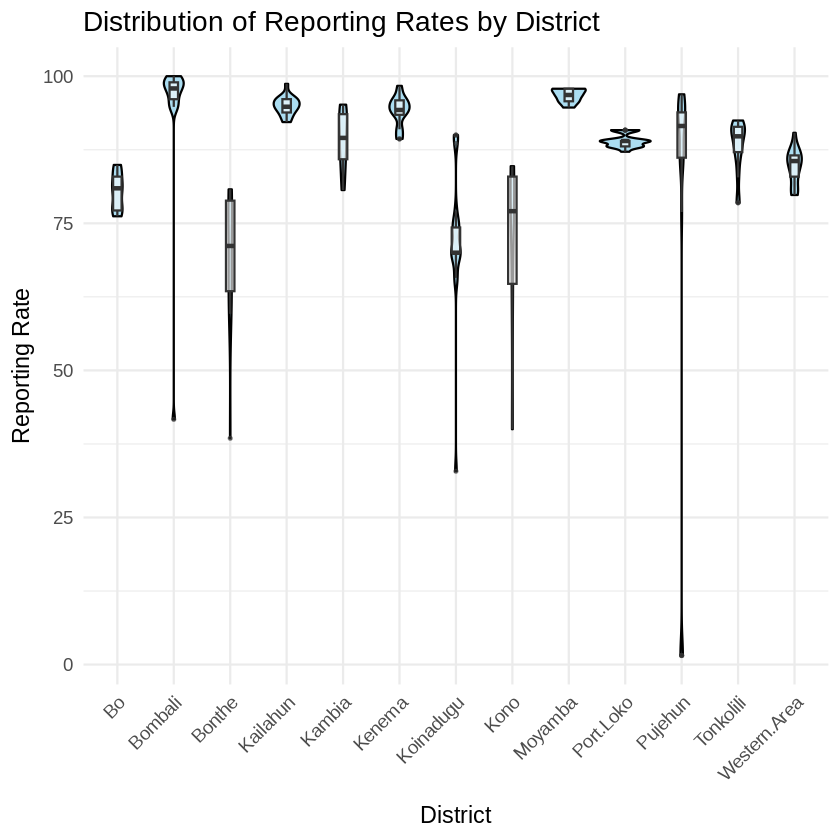

In [ ]:
# Generate Violin Plot to inspect Outliers
ggplot(rhrr_data_long_clean, aes(x = District, y = ReportingRate)) +
  geom_violin(fill = "skyblue", color = "black", alpha = 0.7) +
  geom_boxplot(width = 0.15, outlier.size = 0.8, alpha = 0.6) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Distribution of Reporting Rates by District",
    x = "District",
    y = "Reporting Rate"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


In [ ]:
# Find Outliers by IQR
rhrr_outliers_iqr <- rhrr_data_long_clean %>%
  group_by(District) %>%
  mutate(
    Q1  = quantile(ReportingRate, 0.25, na.rm = TRUE),
    Q3  = quantile(ReportingRate, 0.75, na.rm = TRUE),
    IQR = Q3 - Q1,
    Lower = Q1 - 1.5 * IQR,
    Upper = Q3 + 1.5 * IQR,
    is_outlier = ReportingRate < Lower | ReportingRate > Upper
  ) %>%
  ungroup() %>%
  filter(is_outlier)

rhrr_outliers_iqr

Date,Year,Month,periodcode,District,ReportingRate,Q1,Q3,IQR,Lower,Upper,is_outlier
<date>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
2024-11-01,2024,11,202411,Bombali,41.67,96.0925,98.96,2.8675,91.79125,103.2612,TRUE
2024-10-01,2024,10,202410,Bonthe,38.46,63.4600,78.85,15.3900,40.37500,101.9350,TRUE
2024-01-01,2024,1,202401,Kenema,89.34,93.4400,95.90,2.4600,89.75000,99.5900,TRUE
2025-01-01,2025,1,202501,Kenema,89.34,93.4400,95.90,2.4600,89.75000,99.5900,TRUE
2024-08-01,2024,8,202408,Koinadugu,90.00,70.0000,74.29,4.2900,63.56500,80.7250,TRUE
2024-09-01,2024,9,202409,Koinadugu,90.00,70.0000,74.29,4.2900,63.56500,80.7250,TRUE
2024-10-01,2024,10,202410,Koinadugu,32.86,70.0000,74.29,4.2900,63.56500,80.7250,TRUE
2024-11-01,2024,11,202411,Koinadugu,88.57,70.0000,74.29,4.2900,63.56500,80.7250,TRUE
2024-06-01,2024,6,202406,Port.Loko,90.83,88.0700,88.99,0.9200,86.69000,90.3700,TRUE


In [ ]:
# Over-aggressive Outlier Removal, does not respect seasonal differences in data
# Potentially, do global IQR, and then inspect for outliers through that
iqr_bounds <- rhrr_data_long_clean %>%
  summarise(
    Q1  = quantile(ReportingRate, 0.25, na.rm = TRUE),
    Q3  = quantile(ReportingRate, 0.75, na.rm = TRUE)
  ) %>%
  mutate(
    IQR = Q3 - Q1,
    Lower = Q1 - 1.5 * IQR,
    Upper = Q3 + 1.5 * IQR
  )

  iqr_bounds

Q1,Q3,IQR,Lower,Upper
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
80.77,94.79,14.02,59.74,115.82


In [ ]:
# Nope, still too much
detect_outliers_rolling_mad <- function(df, k = 3, threshold = 3) {
  # Threshold: (2 - Oversensitive, 3 - Standard, 4 - Undersensitive)
  # K: Rolling Window Size

  # Ensure sorted
  df <- df %>% arrange(District, Date)

  # We'll store results for each district here
  output_list <- list()

  districts <- unique(df$District)

  for (dist in districts) {

    df_sub <- df %>% filter(District == dist)

    # Rolling median (centered)
    roll_med <- rollmedian(df_sub$ReportingRate, k = k, fill = NA, align = "center")

    # Residuals from rolling median
    resid <- df_sub$ReportingRate - roll_med

    # MAD on the residuals (robust measure of variability)
    mad_val <- mad(resid, na.rm = TRUE)

    # Outlier flag (sensitivity controlled by threshold)
    outlier_flag <- abs(resid) > threshold * mad_val

    # Attach the results back to the subgroup
    df_sub$RollingMedian <- roll_med
    df_sub$ResidualMAD <- resid
    df_sub$MAD <- mad_val
    df_sub$MAD_Outlier <- outlier_flag

    output_list[[dist]] <- df_sub
  }

  # Combine back into one dataframe
  result <- bind_rows(output_list)
  return(result)
}


In [ ]:
# Apply the Function
rhrr_rolling_mad <- detect_outliers_rolling_mad(
  rhrr_data_long_clean,
  k = 3,          # 3-month rolling window
  threshold = 4   # Minimal Sensitivity, Only Remove Extreme Values
)

rolling_mad_outliers <- rhrr_rolling_mad %>%
  filter(MAD_Outlier == TRUE)

rolling_mad_outliers

Date,Year,Month,periodcode,District,ReportingRate,RollingMedian,ResidualMAD,MAD,MAD_Outlier
<date>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
2024-07-01,2024,7,202407,Bo,84.92,83.33,1.59,0.000000,TRUE
2024-08-01,2024,8,202408,Bo,83.33,84.92,-1.59,0.000000,TRUE
2024-09-01,2024,9,202409,Bo,84.92,84.13,0.79,0.000000,TRUE
2025-03-01,2025,3,202503,Bo,77.78,76.98,0.80,0.000000,TRUE
2025-04-01,2025,4,202504,Bo,76.19,77.78,-1.59,0.000000,TRUE
2024-03-01,2024,3,202403,Bombali,100.00,98.96,1.04,0.000000,TRUE
2024-05-01,2024,5,202405,Bombali,96.88,98.96,-2.08,0.000000,TRUE
2024-09-01,2024,9,202409,Bombali,95.83,97.92,-2.09,0.000000,TRUE
2024-10-01,2024,10,202410,Bombali,97.92,95.83,2.09,0.000000,TRUE


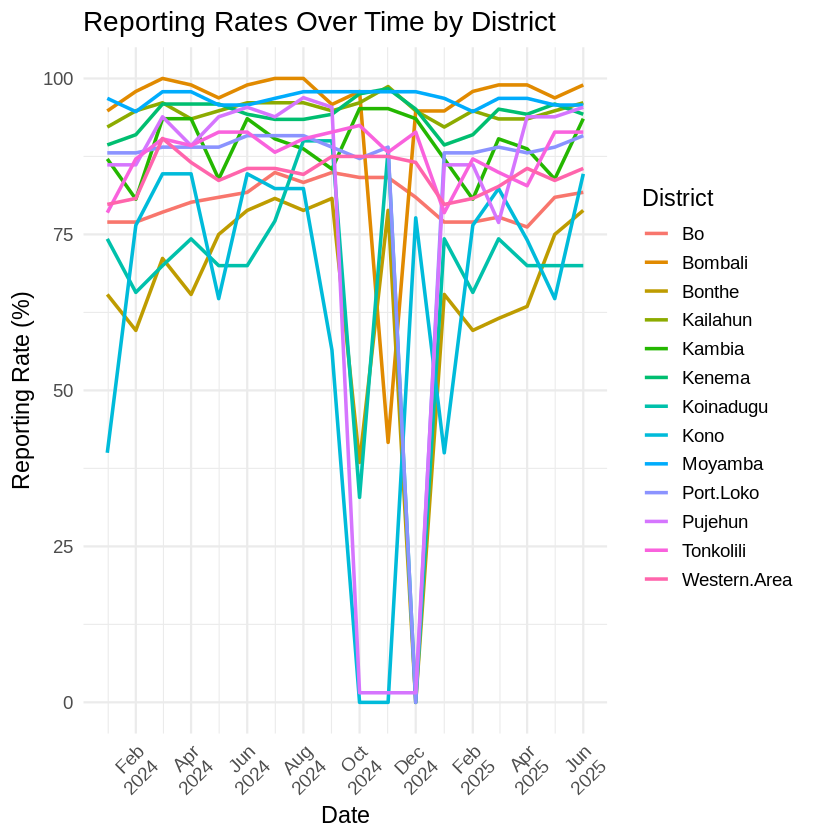

In [ ]:
# The Outlier Area seems to be some sort of shock period
# Inspect per district
ggplot(rhrr_data_long, aes(x = Date, y = ReportingRate, color = District, group = District)) +
  geom_line(linewidth = 1) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Reporting Rates Over Time by District",
    x = "Date",
    y = "Reporting Rate (%)",
    color = "District"
  ) +
  scale_x_date(date_breaks = "2 months", date_labels = "%b\n%Y") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  )


In [ ]:
rhrr_pct_change <- rhrr_data_long %>%
  arrange(District, Date) %>%
  group_by(District) %>%
  mutate(
    PercentChange = (ReportingRate - lag(ReportingRate)) / lag(ReportingRate) * 100
  ) %>%
  ungroup() %>%
  # Remove rows where rate OR previous rate invalid
  filter(
    !is.na(PercentChange),
    ReportingRate != 0,
  )

rhrr_pct_change

Date,Year,Month,periodcode,District,ReportingRate,PercentChange
<date>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
2024-02-01,2024,2,202402,Bo,76.98,0.0000000
2024-03-01,2024,3,202403,Bo,78.57,2.0654716
2024-04-01,2024,4,202404,Bo,80.16,2.0236732
2024-05-01,2024,5,202405,Bo,80.95,0.9855289
2024-06-01,2024,6,202406,Bo,81.75,0.9882644
2024-07-01,2024,7,202407,Bo,84.92,3.8776758
2024-08-01,2024,8,202408,Bo,83.33,-1.8723504
2024-09-01,2024,9,202409,Bo,84.92,1.9080763
2024-10-01,2024,10,202410,Bo,84.13,-0.9302873


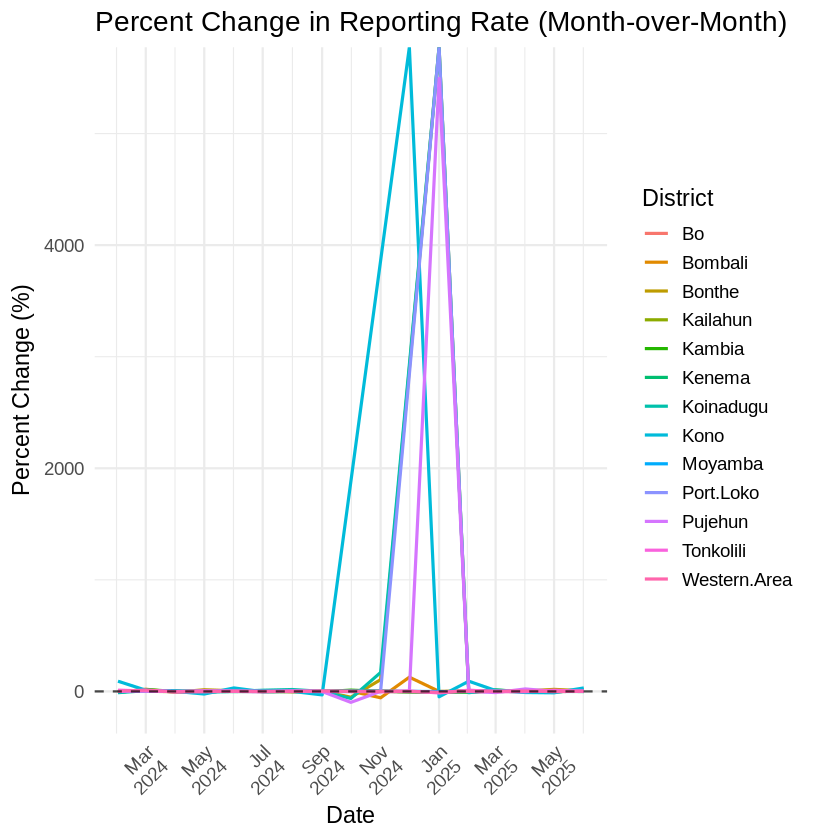

In [ ]:
ggplot(rhrr_pct_change, aes(x = Date, y = PercentChange, color = District, group = District)) +
  geom_line(linewidth = 0.9) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Percent Change in Reporting Rate (Month-over-Month)",
    x = "Date",
    y = "Percent Change (%)",
    color = "District"
  ) +
  scale_x_date(date_breaks = "2 months", date_labels = "%b\n%Y") +
  geom_hline(yintercept = 0, linetype = "dashed", alpha = 0.7) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  )

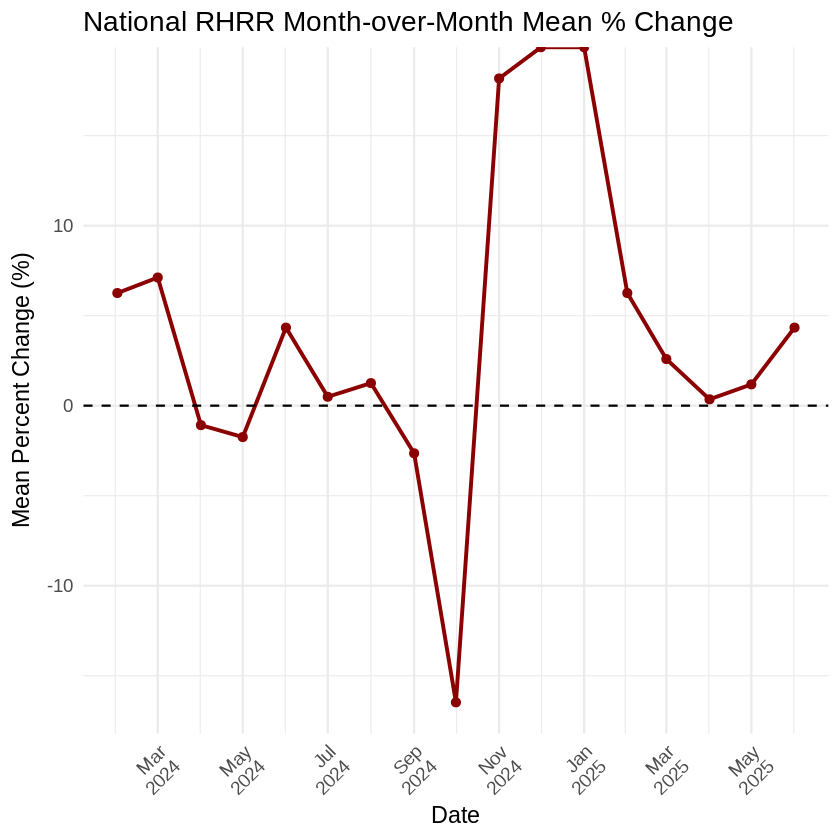

In [ ]:
# Aggregate Per District to visualize on the Sierra Leone Level
pct_change_agg <- rhrr_pct_change %>%
  group_by(Date) %>%
  summarise(
    MeanPctChange = mean(PercentChange, na.rm = TRUE),
    MedianPctChange = median(PercentChange, na.rm = TRUE)
  )

ggplot(pct_change_agg, aes(x = Date, y = MeanPctChange)) +
geom_line(color = "darkred", linewidth = 1.1) +
geom_point(color = "darkred", size = 2) +
theme_minimal(base_size = 14) +
labs(
  title = "National RHRR Month-over-Month Mean % Change",
  x = "Date",
  y = "Mean Percent Change (%)"
) +
scale_x_date(date_breaks = "2 months", date_labels = "%b\n%Y") +
geom_hline(yintercept = 0, linetype = "dashed") +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

# ggplot(pct_change_agg, aes(x = Date, y = MedianPctChange)) +
# geom_line(color = "darkred", linewidth = 1.1) +
# geom_point(color = "darkred", size = 2) +
# theme_minimal(base_size = 14) +
# labs(
#   title = "National RHRR Month-over-Month Median % Change",
#   x = "Date",
#   y = "Mean Percent Change (%)"
# ) +
# scale_x_date(date_breaks = "2 months", date_labels = "%b\n%Y") +
# geom_hline(yintercept = 0, linetype = "dashed") +
# theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [ ]:
# Quantify the Shock Points
rhrr_national_shock <- pct_change_agg %>%
  mutate(AbsMeanPctChange = abs(MeanPctChange)) %>%
  arrange(desc(AbsMeanPctChange))

rhrr_national_shock

Date,MeanPctChange,MedianPctChange,AbsMeanPctChange
<date>,<dbl>,<dbl>,<dbl>
2024-12-01,Inf,-0.5485714,Inf
2025-01-01,Inf,-2.7423268,Inf
2024-11-01,18.1755338,0.0000000,18.1755338
2024-10-01,-16.4773367,0.0000000,16.4773367
2024-03-01,7.1186956,5.4077819,7.1186956
2024-02-01,6.2569187,0.0000000,6.2569187
2025-02-01,6.2569187,0.0000000,6.2569187
2024-06-01,4.3363863,1.6302611,4.3363863
2025-06-01,4.3363863,1.6302611,4.3363863


In [ ]:
# INTERPOLATE MISSING VALUES (Oct,Nov,Dec for 2024)

# Goal is to use stable/non zero districts from previous month to correct the missing data
interpolate_month <- function(df, year, month) {

  cat(sprintf("\n--- INTERPOLATING %04d-%02d ---\n", year, month))

  # Copy dataframe to modify
  df_out <- df

  # Identify zero districts
  zero_districts <- df %>%
    filter(Year == year, Month == month, ReportingRate == 0) %>%
    pull(District)

  cat(sprintf("Zero districts in %04d-%02d: %d\n", year, month, length(zero_districts)))
  print(zero_districts)

  if (length(zero_districts) == 0) return(df_out)

  # Identify stable districts
  stable_districts <- df %>%
    filter(Year == year, Month == month, ReportingRate > 0) %>%
    pull(District)

  cat(sprintf("Stable districts in %04d-%02d: %d\n", year, month, length(stable_districts)))
  print(stable_districts)

  # Calculate mean for previous month (baseline)
  prev_month <- ifelse(month == 1, 12, month - 1)
  prev_year  <- ifelse(month == 1, year - 1, year)

  prev_mean <- df_out %>%
    filter(Year == prev_year, Month == prev_month, District %in% stable_districts) %>%
    summarise(Mean = mean(ReportingRate, na.rm = TRUE)) %>%
    pull(Mean)

  # Mean for current month among stable districts
  curr_mean <- df_out %>%
    filter(Year == year, Month == month, District %in% stable_districts) %>%
    summarise(Mean = mean(ReportingRate, na.rm = TRUE)) %>%
    pull(Mean)

  # Shift amount
  shift <- curr_mean - prev_mean

  cat(sprintf("\nPrev month mean (%04d-%02d): %.2f%%\n", prev_year, prev_month, prev_mean))
  cat(sprintf("Curr month mean (%04d-%02d): %.2f%%\n", year, month, curr_mean))
  cat(sprintf("Calculated shift: %.2f%%\n", shift))

  # Apply shift interpolation to each zero district
  for(district in zero_districts) {
    prev_value <- df_out %>%
      filter(Year == prev_year, Month == prev_month, District == district) %>%
      pull(ReportingRate)

    interpolated_value <- prev_value + shift
    interpolated_value <- max(0, min(100, interpolated_value))

    cat(sprintf("  %s: Prev=%.2f%% → Interpolated=%.2f%%\n",
                district, prev_value, interpolated_value))

    df_out <- df_out %>%
      mutate(ReportingRate = ifelse(
        District == district & Year == year & Month == month,
        interpolated_value,
        ReportingRate
      ))
  }

  return(df_out)
}


In [ ]:
# Start with long dataframe
rhrr_interpolated <- rhrr_data_long

# October 2024
rhrr_interpolated <- interpolate_month(rhrr_interpolated, 2024, 10)

# November 2024
rhrr_interpolated <- interpolate_month(rhrr_interpolated, 2024, 11)

# December 2024
rhrr_interpolated <- interpolate_month(rhrr_interpolated, 2024, 12)


--- INTERPOLATING 2024-10 ---
Zero districts in 2024-10: 1
[1] "Kono"
Stable districts in 2024-10: 12
 [1] "Bo"           "Bombali"      "Bonthe"       "Kailahun"     "Kambia"      
 [6] "Kenema"       "Koinadugu"    "Moyamba"      "Port.Loko"    "Pujehun"     
[11] "Tonkolili"    "Western.Area"

Prev month mean (2024-09): 90.60%
Curr month mean (2024-10): 75.73%
Calculated shift: -14.88%
  Kono: Prev=56.47% → Interpolated=41.59%

--- INTERPOLATING 2024-11 ---
Zero districts in 2024-11: 1
[1] "Kono"
Stable districts in 2024-11: 12
 [1] "Bo"           "Bombali"      "Bonthe"       "Kailahun"     "Kambia"      
 [6] "Kenema"       "Koinadugu"    "Moyamba"      "Port.Loko"    "Pujehun"     
[11] "Tonkolili"    "Western.Area"

Prev month mean (2024-10): 75.73%
Curr month mean (2024-11): 79.13%
Calculated shift: 3.40%
  Kono: Prev=41.59% → Interpolated=45.00%

--- INTERPOLATING 2024-12 ---
Zero districts in 2024-12: 3
[1] "Bonthe"    "Koinadugu" "Port.Loko"
Stable districts in 2024-12: 10


In [ ]:
# Filter out Elements where Reporting Rate was 0 or is NA
zero_reporting_interpolated <- rhrr_interpolated %>%
  filter(ReportingRate == 0 | is.na(ReportingRate))

zero_reporting_interpolated

Date,Year,Month,periodcode,District,ReportingRate
<date>,<int>,<int>,<int>,<chr>,<dbl>


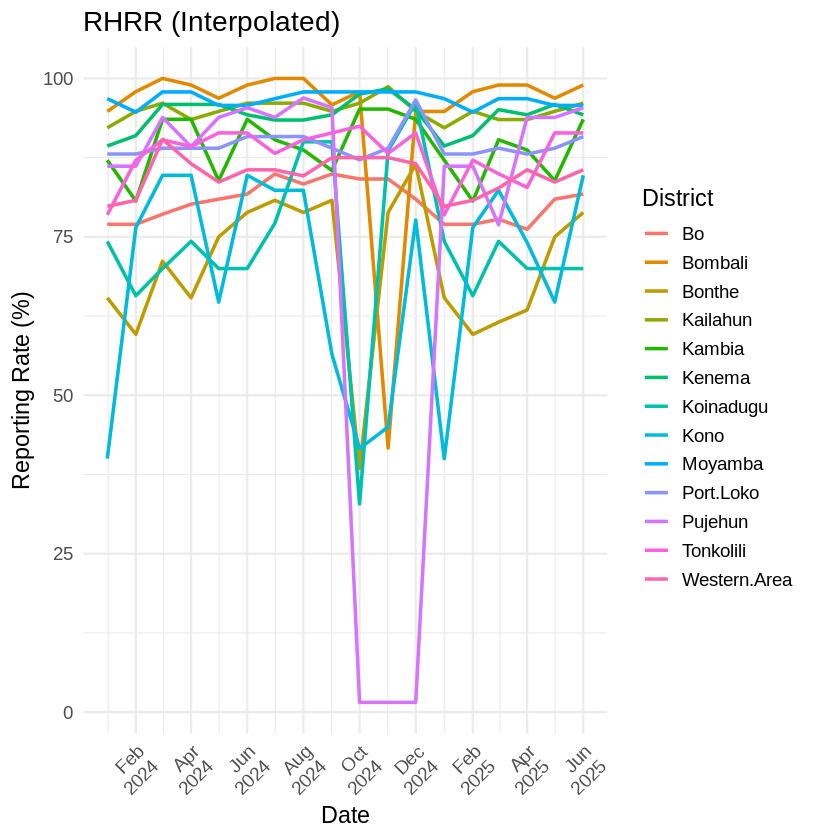

In [ ]:
# Inspect per district again with interpolated date
ggplot(rhrr_interpolated, aes(x = Date, y = ReportingRate, color = District, group = District)) +
  geom_line(linewidth = 1) +
  theme_minimal(base_size = 14) +
  labs(
    title = "RHRR (Interpolated)",
    x = "Date",
    y = "Reporting Rate (%)",
    color = "District"
  ) +
  scale_x_date(date_breaks = "2 months", date_labels = "%b\n%Y") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  )


In [ ]:
# Using Interpolated Data now
# Calculate overall reporting rate (average across all districts)
rhrr_data_overall <- rhrr_interpolated %>%
  group_by(Date, Year, Month) %>%
  summarise(
    MeanRate   = mean(ReportingRate),
    MedianRate = median(ReportingRate),
    SDRate     = sd(ReportingRate),
    MinRate    = min(ReportingRate),
    MaxRate    = max(ReportingRate),
    .groups = "drop"
  )

cat("Summary statistics by month:\n")
print(rhrr_data_overall)

Summary statistics by month:
# A tibble: 18 × 8
   Date        Year Month MeanRate MedianRate SDRate MinRate MaxRate
   <date>     <int> <int>    <dbl>      <dbl>  <dbl>   <dbl>   <dbl>
 1 2024-01-01  2024     1     80.7       86.2  15.1    40       96.8
 2 2024-02-01  2024     2     83.1       86.2  11.4    59.6     97.9
 3 2024-03-01  2024     3     88.6       90.4   9.79   70      100  
 4 2024-04-01  2024     4     87.6       89.2   9.65   65.4     99.0
 5 2024-05-01  2024     5     85.8       89.0  10.6    64.7     96.9
 6 2024-06-01  2024     6     89.0       91.4   8.37   70       99.0
 7 2024-07-01  2024     7     89.3       90.3   6.84   77.1    100  
 8 2024-08-01  2024     8     90.3       90.3   6.56   78.8    100  
 9 2024-09-01  2024     9     88.0       90    10.7    56.5     97.9
10 2024-10-01  2024    10     73.1       87.5  32.5     1.54    97.9
11 2024-11-01  2024    11     76.5       88.2  29.2     1.54    98.7
12 2024-12-01  2024    12     84.1       93.6  25.6    

In [ ]:
# Create the TS Object
df_to_ts <- function(data, date_col, value_col) {
  # Ensure date column is Date
  data[[date_col]] <- as.Date(data[[date_col]])

  # Sort by date just in case
  data <- data[order(data[[date_col]]), ]

  # Extract start year and month
  start_year  <- lubridate::year(data[[date_col]][1])
  start_month <- lubridate::month(data[[date_col]][1])

  # Extract numeric vector of the time series values
  values <- data[[value_col]]

  # Create monthly time series
  ts_obj <- ts(
    values,
    start = c(start_year, start_month),
    frequency = 12
  )

  return(ts_obj)
}

# Create the:
# Reproductive Health Reporting Rate Sierra Leone Time Series
rhrr_sl_ts <- df_to_ts(
  data = rhrr_data_overall,
  date_col = "Date",
  value_col = "MeanRate"
)

rhrr_sl_ts

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2024,80.72462,83.07000,88.56846,87.56462,85.82692,89.00846,89.25231,90.25692,87.97538,73.10038,76.50038,84.10888
2025,80.72462,83.07000,84.93769,85.10154,85.82692,89.00846,,,,,,


[Resource](https://openstax.org/books/principles-data-science/pages/5-2-components-of-time-series-analysis)
1. **Trend**. The long-term direction of time series data in the absence of any other variation.
2. **Cyclic component**. Large variations in the data that recur over longer time periods than seasonal fluctuations but not with a fixed frequency.
3. **Seasonal component** (often referred to as seasonality). Variation in the data that occurs at fixed time periods, such as every year in the same months or every week on the same days.
4. **Noise/Random Error**. Random, unpredictable variations that occur in the time series that cannot be attributed to any of the other components previously listed. (Note, the term “random” is not the same as statistically independent.)

In [ ]:
# ============================================================================
# INTERNAL HELPER: Extract time series properties
# ============================================================================
.extract_ts_properties <- function(ts_obj) {

  if (!is.ts(ts_obj)) {
    stop("Input must be a ts (time series) object")
  }

  properties <- list(
    ts_object = ts_obj,
    n_obs = length(ts_obj),
    frequency = frequency(ts_obj),
    start_time = start(ts_obj),
    end_time = end(ts_obj),
    start_year = start(ts_obj)[1],
    start_month = start(ts_obj)[2],
    end_year = end(ts_obj)[1],
    end_month = end(ts_obj)[2],
    n_years = length(ts_obj) / frequency(ts_obj)
  )

  return(properties)
}

# ============================================================================
# COMPONENT 1: TREND ANALYSIS
# ============================================================================
analyze_trend <- function(ts_obj, verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n--- COMPONENT 1: TREND ---\n")
  }

  # Linear trend
  time_index <- 1:props$n_obs
  trend_model <- lm(as.numeric(ts_obj) ~ time_index)
  trend_fitted <- fitted(trend_model)

  slope <- coef(trend_model)[2]
  intercept <- coef(trend_model)[1]
  r_squared <- summary(trend_model)$r.squared
  p_value <- summary(trend_model)$coefficients[2, 4]

  if(verbose) {
    cat(sprintf("Linear Trend: y = %.3f + %.3f*t\n", intercept, slope))
    cat(sprintf("Slope: %.3f%% per month", slope))

    if(p_value < 0.001) {
      cat(" (p < 0.001) ***\n")
    } else if(p_value < 0.01) {
      cat(sprintf(" (p = %.3f) **\n", p_value))
    } else if(p_value < 0.05) {
      cat(sprintf(" (p = %.3f) *\n", p_value))
    } else {
      cat(sprintf(" (p = %.3f) not significant\n", p_value))
    }

    cat(sprintf("R-squared: %.3f (%.1f%% of variation)\n", r_squared, r_squared*100))
    cat(sprintf("Total change over period: %.2f%%\n", slope * props$n_obs))

    if(slope > 0.1) {
      cat("Interpretation: INCREASING trend\n")
    } else if(slope < -0.1) {
      cat("Interpretation: DECREASING trend\n")
    } else {
      cat("Interpretation: RELATIVELY STABLE (flat trend)\n")
    }
  }

  # Moving averages
  ma_3 <- forecast::ma(ts_obj, order = 3)
  ma_6 <- forecast::ma(ts_obj, order = 6)

  results <- list(
    trend_model = trend_model,
    trend_slope = slope,
    trend_intercept = intercept,
    trend_rsquared = r_squared,
    trend_pvalue = p_value,
    trend_fitted = trend_fitted,
    ma_3 = ma_3,
    ma_6 = ma_6,
    interpretation = if(slope > 0.1) "INCREASING" else if(slope < -0.1) "DECREASING" else "STABLE"
  )

  return(results)
}

# ============================================================================
# COMPONENT 2: SEASONALITY ANALYSIS
# ============================================================================
analyze_seasonality <- function(ts_obj, verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n--- COMPONENT 2: SEASONALITY ---\n")
    cat(sprintf("⚠️  Data span: %.1f years (%d months)\n", props$n_years, props$n_obs))

    if(props$n_years < 2) {
      cat("LIMITATION: Less than 2 full years - seasonal assessment LIMITED\n")
      cat("Recommendation: Need 24+ months for robust seasonality\n")
    }
  }

  # Calculate pattern by cycle (monthly for frequency=12)
  cycle_pattern <- tapply(as.numeric(ts_obj), cycle(ts_obj), mean, na.rm = TRUE)

  if(verbose) {
    cat("\nCycle Averages:\n")
    for(i in 1:length(cycle_pattern)) {
      if(!is.na(cycle_pattern[i])) {
        cycle_name <- if(props$frequency == 12) month.abb[i] else paste("Period", i)
        cat(sprintf("  %s: %.2f%%\n", cycle_name, cycle_pattern[i]))
      }
    }
  }

  peak_period <- which.max(cycle_pattern)
  low_period <- which.min(cycle_pattern)
  seasonal_range <- max(cycle_pattern, na.rm = TRUE) - min(cycle_pattern, na.rm = TRUE)

  if(verbose) {
    cat(sprintf("\nSeasonal Pattern:\n"))
    peak_name <- if(props$frequency == 12) month.abb[peak_period] else paste("Period", peak_period)
    low_name <- if(props$frequency == 12) month.abb[low_period] else paste("Period", low_period)
    cat(sprintf("  Peak: %s (%.2f%%)\n", peak_name, cycle_pattern[peak_period]))
    cat(sprintf("  Trough: %s (%.2f%%)\n", low_name, cycle_pattern[low_period]))
    cat(sprintf("  Range: %.2f%%\n", seasonal_range))
  }

  # Seasonal strength (if enough data)
  seasonal_strength <- NA
  if(props$n_obs >= 24) {
    decomp_temp <- decompose(ts_obj, type = "additive")
    seasonal_var <- var(decomp_temp$seasonal, na.rm = TRUE)
    remainder_var <- var(decomp_temp$random, na.rm = TRUE)
    seasonal_strength <- 1 - (remainder_var / (seasonal_var + remainder_var))
  }

  results <- list(
    cycle_pattern = cycle_pattern,
    peak_period = peak_period,
    low_period = low_period,
    seasonal_range = seasonal_range,
    seasonal_strength = seasonal_strength,
    data_sufficient = props$n_years >= 2
  )

  return(results)
}

# ============================================================================
# COMPONENT 3: CYCLICAL ANALYSIS
# ============================================================================
analyze_cyclical <- function(ts_obj, verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n--- COMPONENT 3: CYCLICAL ---\n")
    cat("ASSESSMENT: Cannot determine with current data length\n")
    cat(sprintf("Rationale: Only %.1f years of data\n", props$n_years))
    cat("Requirement: Cyclical patterns need 3-10+ years\n")
    cat("Conclusion: INSUFFICIENT DATA for cyclical analysis\n")
  }

  results <- list(
    can_assess = props$n_years >= 3,
    years_available = props$n_years,
    years_needed = 3,
    conclusion = "INSUFFICIENT DATA"
  )

  return(results)
}

# ============================================================================
# COMPONENT 4: IRREGULAR/RANDOM ANALYSIS
# ============================================================================
analyze_irregular <- function(ts_obj, trend_fitted = NULL, verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n--- COMPONENT 4: IRREGULAR/RANDOM ---\n")
  }

  # If no trend provided, calculate it
  if(is.null(trend_fitted)) {
    time_index <- 1:props$n_obs
    trend_model <- lm(as.numeric(ts_obj) ~ time_index)
    trend_fitted <- fitted(trend_model)
  }

  # Residuals after removing trend
  residuals <- as.numeric(ts_obj) - trend_fitted
  residuals_ts <- ts(residuals, start = props$start_time, frequency = props$frequency)

  resid_mean <- mean(residuals, na.rm = TRUE)
  resid_sd <- sd(residuals, na.rm = TRUE)
  resid_min <- min(residuals, na.rm = TRUE)
  resid_max <- max(residuals, na.rm = TRUE)

  if(verbose) {
    cat(sprintf("Residuals (after removing trend):\n"))
    cat(sprintf("  Mean: %.3f%% (should be ~0)\n", resid_mean))
    cat(sprintf("  SD: %.3f%%\n", resid_sd))
    cat(sprintf("  Range: %.2f%% to %.2f%%\n", resid_min, resid_max))
  }

  # Outlier detection
  outlier_threshold <- 1.5 * resid_sd
  outliers <- which(abs(residuals) > outlier_threshold)

  if(verbose) {
    cat(sprintf("\nOutliers (>1.5 SD from mean): %d observations\n", length(outliers)))
    if(length(outliers) > 0 & length(outliers) <= 5) {
      for(i in outliers) {
        cat(sprintf("  Month %d: %.2f%% deviation\n", i, residuals[i]))
      }
    } else if(length(outliers) > 5) {
      cat(sprintf("  (Too many to list - %d total)\n", length(outliers)))
    }
  }

  # Randomness test
  lb_test <- Box.test(residuals, lag = min(10, floor(props$n_obs/2)), type = "Ljung-Box")

  if(verbose) {
    cat(sprintf("\nLjung-Box Test (lag=%d):\n", min(10, floor(props$n_obs/2))))
    cat(sprintf("  Chi-squared: %.3f\n", lb_test$statistic))
    cat(sprintf("  p-value: %.4f\n", lb_test$p.value))

    if(lb_test$p.value > 0.05) {
      cat("  Result: Residuals appear RANDOM (good!)\n")
    } else {
      cat("  Result: Residuals show AUTOCORRELATION (structure remains)\n")
    }
  }


  results <- list(
    residuals = residuals_ts,
    residual_mean = resid_mean,
    residual_sd = resid_sd,
    residual_min = resid_min,
    residual_max = resid_max,
    outliers = outliers,
    outlier_threshold = outlier_threshold,
    ljungbox_test = lb_test,
    is_random = lb_test$p.value > 0.05
  )

  return(results)
}

# # ============================================================================
# # DECOMPOSITION ANALYSIS
# # ============================================================================
# analyze_decomposition <- function(ts_obj, verbose = TRUE) {

#   props <- .extract_ts_properties(ts_obj)

#   if(verbose) {
#     cat("\n--- CLASSICAL DECOMPOSITION ---\n")
#   }

#   decomp_add <- NULL
#   decomp_mult <- NULL
#   method_used <- NULL

#   # Check if we have at least 2 full periods
#   if(props$n_obs < 2 * props$frequency) {
#     if(verbose) {
#       cat("⚠️  WARNING: Less than 2 full periods\n")
#       cat(sprintf("   Data: %d observations, Need: %d (2 × frequency)\n",
#                   props$n_obs, 2 * props$frequency))
#       cat("   Cannot perform seasonal decomposition\n")
#       cat("   Decomposition requires at least 2 complete seasonal cycles\n")
#     }

#     results <- list(
#       decomposition_add = NULL,
#       decomposition_mult = NULL,
#       method_used = "none",
#       sufficient_data = FALSE,
#       reason = "Less than 2 full periods"
#     )

#     return(results)
#   }

#   # We have enough data for decomposition
#   if(props$n_obs >= 24) {
#     if(verbose) cat("Using classical decomposition (24+ observations)\n")

#     tryCatch({
#       decomp_add <- decompose(ts_obj, type = "additive")
#       method_used <- "classical_additive"

#       if(verbose) cat("Additive decomposition: Y = Trend + Seasonal + Random\n")

#       if(min(ts_obj, na.rm = TRUE) > 0) {
#         decomp_mult <- decompose(ts_obj, type = "multiplicative")
#         if(verbose) cat("Multiplicative decomposition: Y = Trend × Seasonal × Random\n")
#       } else {
#         if(verbose) cat("Multiplicative: Skipped (contains zeros/negatives)\n")
#       }
#     }, error = function(e) {
#       if(verbose) cat("Error in classical decomposition:", e$message, "\n")
#       decomp_add <<- NULL
#       method_used <<- "error"
#     })

#   } else {
#     # Between 2*frequency and 24 observations - use STL
#     if(verbose) {
#       cat("Using STL decomposition (less than 24 observations)\n")
#     }

#     tryCatch({
#       decomp_add <- stl(ts_obj, s.window = "periodic")
#       method_used <- "stl"
#       if(verbose) cat("STL decomposition: Y = Trend + Seasonal + Remainder\n")
#     }, error = function(e) {
#       if(verbose) cat("Error in STL decomposition:", e$message, "\n")
#       decomp_add <<- NULL
#       method_used <<- "error"
#     })
#   }

#   results <- list(
#     decomposition_add = decomp_add,
#     decomposition_mult = decomp_mult,
#     method_used = method_used,
#     sufficient_data = !is.null(decomp_add),
#     n_periods = props$n_obs / props$frequency
#   )

#   return(results)

# ============================================================================
# MASTER FUNCTION: Analyze all components
# ============================================================================
analyze_ts_components <- function(ts_obj, series_name = "Time Series", verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n============================================================================\n")
    cat(sprintf("TIME SERIES COMPONENT ANALYSIS: %s\n", series_name))
    cat("============================================================================\n\n")
    cat(sprintf("Observations: %d\n", props$n_obs))
    cat(sprintf("Frequency: %d (per year)\n", props$frequency))
    cat(sprintf("Period: %d-%02d to %d-%02d\n",
                props$start_year, props$start_month,
                props$end_year, props$end_month))
  }

  # Analyze each component
  trend_results <- analyze_trend(ts_obj, verbose = verbose)
  seasonal_results <- analyze_seasonality(ts_obj, verbose = verbose)
  cyclical_results <- analyze_cyclical(ts_obj, verbose = verbose)
  irregular_results <- analyze_irregular(ts_obj,
                                         trend_fitted = trend_results$trend_fitted,
                                         verbose = verbose)
  #decomp_results <- analyze_decomposition(ts_obj, verbose = verbose)

  # Combine all results
  all_results <- list(
    # Metadata
    series_name = series_name,
    ts_object = ts_obj,
    properties = props,

    # Components
    trend = trend_results,
    seasonal = seasonal_results,
    cyclical = cyclical_results,
    irregular = irregular_results
    #decomposition = decomp_results
  )

  if(verbose) {
    cat("\n============================================================================\n")
    cat("Analysis complete! Results stored in list object.\n")
    cat("============================================================================\n")
  }

  return(invisible(all_results))
}

In [ ]:
analyze_ts_components(rhrr_sl_ts, series_name = "Reproductive Health Reporting Rate in Sierra Leone from Jan 2024 to Jun 2025")


TIME SERIES COMPONENT ANALYSIS: Reproductive Health Reporting Rate in Sierra Leone from Jan 2024 to Jun 2025

Observations: 18
Frequency: 12 (per year)
Period: 2024-01 to 2025-06

--- COMPONENT 1: TREND ---
Linear Trend: y = 85.255 + -0.058*t
Slope: -0.058% per month (p = 0.791) not significant
R-squared: 0.005 (0.5% of variation)
Total change over period: -1.05%
Interpretation: RELATIVELY STABLE (flat trend)

--- COMPONENT 2: SEASONALITY ---
⚠️  Data span: 1.5 years (18 months)
LIMITATION: Less than 2 full years - seasonal assessment LIMITED
Recommendation: Need 24+ months for robust seasonality

Cycle Averages:
  Jan: 80.72%
  Feb: 83.07%
  Mar: 86.75%
  Apr: 86.33%
  May: 85.83%
  Jun: 89.01%
  Jul: 89.25%
  Aug: 90.26%
  Sep: 87.98%
  Oct: 73.10%
  Nov: 76.50%
  Dec: 84.11%

Seasonal Pattern:
  Peak: Aug (90.26%)
  Trough: Oct (73.10%)
  Range: 17.16%

--- COMPONENT 3: CYCLICAL ---
ASSESSMENT: Cannot determine with current data length
Rationale: Only 1.5 years of data
Requirement:

In [ ]:
Date	Year	Month	periodcode	District	ReportingRate
<date>	<int>	<int>	<int>	<chr>	<dbl>
2024-01-01	2024	1	202401	Bo	76.98

Date,Year,Month,periodcode,District,ReportingRate
<date>,<int>,<int>,<int>,<chr>,<dbl>
2024-01-01,2024,1,202401,Bo,76.98
2024-02-01,2024,2,202402,Bo,76.98
2024-03-01,2024,3,202403,Bo,78.57
2024-04-01,2024,4,202404,Bo,80.16
2024-05-01,2024,5,202405,Bo,80.95
2024-06-01,2024,6,202406,Bo,81.75
2024-07-01,2024,7,202407,Bo,84.92
2024-08-01,2024,8,202408,Bo,83.33
2024-09-01,2024,9,202409,Bo,84.92


In [ ]:
# ============================================================================
# DECOMPOSITION ANALYSIS (Manual - for limited data)
# ============================================================================

manual_decompose <- function(ts_obj, model = "additive", verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n============================================================================\n")
    cat("MANUAL TIME SERIES DECOMPOSITION\n")
    cat("============================================================================\n")
    cat(sprintf("Model: %s\n", toupper(model)))
    cat(sprintf("Formula: Observed = Trend %s Seasonal %s Residual\n",
                ifelse(model == "additive", "+", "×"),
                ifelse(model == "additive", "+", "×")))
  }

  # Step 1: Extract TREND using moving average
  # Use centered moving average with window = frequency
  if(props$n_obs >= props$frequency) {
    trend <- stats::filter(ts_obj,
                          filter = rep(1/props$frequency, props$frequency),
                          sides = 2)
  } else {
    # If not enough data, use simple linear trend
    time_index <- 1:props$n_obs
    trend_model <- lm(as.numeric(ts_obj) ~ time_index)
    trend <- ts(fitted(trend_model),
                start = props$start_time,
                frequency = props$frequency)
  }

  # Step 2: Detrend to get seasonal + random
  if(model == "additive") {
    detrended <- ts_obj - trend
  } else {  # multiplicative
    detrended <- ts_obj / trend
  }

  # Step 3: Extract SEASONAL component (average by cycle)
  seasonal_avg <- tapply(as.numeric(detrended),
                         cycle(ts_obj),
                         mean,
                         na.rm = TRUE)

  # For additive model, center around zero
  # For multiplicative model, center around one
  if(model == "additive") {
    seasonal_avg <- seasonal_avg - mean(seasonal_avg, na.rm = TRUE)
  } else {
    seasonal_avg <- seasonal_avg / mean(seasonal_avg, na.rm = TRUE)
  }

  # Replicate seasonal pattern to match length of series
  seasonal <- ts(rep(seasonal_avg, length.out = props$n_obs),
                 start = props$start_time,
                 frequency = props$frequency)

  # Step 4: Calculate RESIDUAL/RANDOM component
  if(model == "additive") {
    random <- ts_obj - trend - seasonal
  } else {  # multiplicative
    random <- ts_obj / (trend * seasonal)
  }

  # Verification: check if decomposition adds up
  if(model == "additive") {
    reconstructed <- trend + seasonal + random
  } else {
    reconstructed <- trend * seasonal * random
  }

  # Calculate reconstruction error
  recon_error <- mean(abs(ts_obj - reconstructed), na.rm = TRUE)

  if(verbose) {
    cat("\nComponent Statistics:\n")
    cat(sprintf("  Trend range: %.2f to %.2f\n",
                min(trend, na.rm = TRUE), max(trend, na.rm = TRUE)))
    cat(sprintf("  Seasonal range: %.2f to %.2f\n",
                min(seasonal, na.rm = TRUE), max(seasonal, na.rm = TRUE)))
    cat(sprintf("  Random SD: %.3f\n", sd(random, na.rm = TRUE)))
    cat(sprintf("  Reconstruction error: %.4f\n", recon_error))

    # Show verification for a random point
    idx <- round(props$n_obs / 2)
    if(model == "additive") {
      cat(sprintf("\nVerification (observation %d):\n", idx))
      cat(sprintf("  Observed %.3f = (Trend %.3f + Seasonal %.3f + Residual %.3f)\n",
                  as.numeric(ts_obj)[idx],
                  as.numeric(trend)[idx],
                  as.numeric(seasonal)[idx],
                  as.numeric(random)[idx]))
    } else {
      cat(sprintf("\nVerification (observation %d):\n", idx))
      cat(sprintf("  Observed %.3f = (Trend %.3f × Seasonal %.3f × Residual %.3f)\n",
                  as.numeric(ts_obj)[idx],
                  as.numeric(trend)[idx],
                  as.numeric(seasonal)[idx],
                  as.numeric(random)[idx]))
    }
  }

  # Create decompose-like structure
  decomp_result <- list(
    x = ts_obj,
    seasonal = seasonal,
    trend = trend,
    random = random,
    figure = seasonal_avg,
    type = model,
    method = "manual_moving_average"
  )
  class(decomp_result) <- "decomposed.ts"

  return(decomp_result)
}

# ============================================================================
# PLOT DECOMPOSITION
# ============================================================================

plot_decomposition <- function(decomp, save_plot = TRUE, filename = "decomposition.png") {
  # SHOW in RStudio
  plot(decomp)

  # SAVE
  if(save_plot) {
    png(filename, width = 1000, height = 800)
    plot(decomp)
    dev.off()
  }
}

# ============================================================================
# DETREND TIME SERIES
# ============================================================================

detrend_ts <- function(ts_obj, method = "linear", verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n============================================================================\n")
    cat("DETRENDING TIME SERIES\n")
    cat("============================================================================\n")
    cat(sprintf("Method: %s\n", method))
  }

  if(method == "linear") {
    # Method 1: Subtract line of best fit
    time_index <- 1:props$n_obs
    trend_model <- lm(as.numeric(ts_obj) ~ time_index)
    trend_fitted <- fitted(trend_model)
    detrended <- ts_obj - trend_fitted

    if(verbose) {
      cat("Linear trend model:\n")
      cat(sprintf("  y = %.3f + %.3f*t\n",
                  coef(trend_model)[1],
                  coef(trend_model)[2]))
      cat(sprintf("  R-squared: %.3f\n", summary(trend_model)$r.squared))
    }

  } else if(method == "moving_average") {
    # Method 2: Subtract moving average trend
    trend_fitted <- stats::filter(ts_obj,
                                  filter = rep(1/props$frequency, props$frequency),
                                  sides = 2)
    detrended <- ts_obj - trend_fitted

    if(verbose) {
      cat(sprintf("Moving average window: %d periods\n", props$frequency))
    }

  } else if(method == "difference") {
    # Method 3: First difference
    detrended <- diff(ts_obj, differences = 1)
    trend_fitted <- ts_obj - c(NA, detrended)

    if(verbose) {
      cat("First difference applied\n")
    }

  } else if(method == "mean") {
    # Method 4: Subtract mean (simple centering)
    trend_fitted <- mean(ts_obj, na.rm = TRUE)
    detrended <- ts_obj - trend_fitted

    if(verbose) {
      cat(sprintf("Mean: %.3f\n", trend_fitted))
    }
  }

  # Convert detrended to ts object if not already
  if(!is.ts(detrended)) {
    detrended <- ts(detrended, start = props$start_time, frequency = props$frequency)
  }

  if(verbose) {
    cat("\nDetrended series statistics:\n")
    cat(sprintf("  Mean: %.3f (should be ~0)\n", mean(detrended, na.rm = TRUE)))
    cat(sprintf("  SD: %.3f\n", sd(detrended, na.rm = TRUE)))
    cat(sprintf("  Range: %.2f to %.2f\n",
                min(detrended, na.rm = TRUE),
                max(detrended, na.rm = TRUE)))
  }

  result <- list(
    original = ts_obj,
    detrended = detrended,
    trend = trend_fitted,
    method = method
  )

  return(result)
}

# ============================================================================
# PLOT DETRENDING COMPARISON
# ============================================================================

plot_detrend <- function(detrend_result, save_plot = TRUE, filename = "detrend.png") {

  if(save_plot) {
    png(filename, width = 1200, height = 800)
  }

  par(mfrow = c(3, 1))

  # Original series
  plot(detrend_result$original,
       main = "Original Time Series",
       ylab = "Value",
       col = "blue",
       lwd = 2)
  if(is.ts(detrend_result$trend)) {
    lines(detrend_result$trend, col = "red", lwd = 2, lty = 2)
    legend("topleft", legend = c("Original", "Trend"),
           col = c("blue", "red"), lty = c(1, 2), lwd = 2)
  }
  grid()

  # Trend component
  if(is.ts(detrend_result$trend)) {
    plot(detrend_result$trend,
         main = "Extracted Trend Component",
         ylab = "Trend",
         col = "red",
         lwd = 2)
  } else {
    plot(detrend_result$original,
         main = "Trend Component (Constant)",
         ylab = "Trend",
         type = "n")
    abline(h = detrend_result$trend, col = "red", lwd = 2)
  }
  grid()

  # Detrended series
  plot(detrend_result$detrended,
       main = paste("Detrended Series -", detrend_result$method),
       ylab = "Detrended Value",
       col = "darkgreen",
       lwd = 2)
  abline(h = 0, col = "red", lty = 2)
  grid()

  # SHOW in RStudio
  par(mfrow = c(3, 1))
  plot(detrend_result$original, ...)
  plot(detrend_result$trend, ...)
  plot(detrend_result$detrended, ...)
  par(mfrow = c(1, 1))

  # SAVE
  if(save_plot) {
    png(filename, width = 1200, height = 800)
    par(mfrow = c(3, 1))
    plot(detrend_result$original, ...)
    plot(detrend_result$trend, ...)
    plot(detrend_result$detrended, ...)
    par(mfrow = c(1, 1))
    dev.off()
  }

# ============================================================================
# DESEASONALIZE TIME SERIES
# ============================================================================

deseasonalize_ts <- function(ts_obj, model = "additive", method = "decomposition", verbose = TRUE) {

  props <- .extract_ts_properties(ts_obj)

  if(verbose) {
    cat("\n============================================================================\n")
    cat("DESEASONALIZING TIME SERIES\n")
    cat("============================================================================\n")
    cat(sprintf("Model: %s\n", model))
    cat(sprintf("Method: %s\n", method))
  }

  if(method == "decomposition") {
    # Use decomposition to extract seasonal component
    decomp <- manual_decompose(ts_obj, model = model, verbose = FALSE)
    seasonal <- decomp$seasonal

    if(model == "additive") {
      deseasonalized <- ts_obj - seasonal
    } else {
      deseasonalized <- ts_obj / seasonal
    }

  } else if(method == "moving_average") {
    # Moving average with seasonal window
    ma <- stats::filter(ts_obj,
                       filter = rep(1/props$frequency, props$frequency),
                       sides = 2)
    deseasonalized <- ma
    seasonal <- ts_obj - ma  # Residual contains seasonal

  } else if(method == "seasonal_difference") {
    # Seasonal differencing
    deseasonalized <- diff(ts_obj, lag = props$frequency)
    seasonal <- ts_obj - c(rep(NA, props$frequency), deseasonalized)
  }

  if(verbose) {
    cat("\nDeseasonalized series statistics:\n")
    cat(sprintf("  Mean: %.3f\n", mean(deseasonalized, na.rm = TRUE)))
    cat(sprintf("  SD: %.3f\n", sd(deseasonalized, na.rm = TRUE)))
    cat(sprintf("  Range: %.2f to %.2f\n",
                min(deseasonalized, na.rm = TRUE),
                max(deseasonalized, na.rm = TRUE)))

    # Compare variability
    orig_sd <- sd(ts_obj, na.rm = TRUE)
    deseas_sd <- sd(deseasonalized, na.rm = TRUE)
    reduction <- (1 - deseas_sd/orig_sd) * 100

    cat(sprintf("\nVariability reduction: %.1f%%\n", reduction))
  }

  result <- list(
    original = ts_obj,
    deseasonalized = deseasonalized,
    seasonal = seasonal,
    model = model,
    method = method
  )

  return(result)
}

# ============================================================================
# PLOT DESEASONALIZATION
# ============================================================================

plot_deseasonalize <- function(deseas_result, save_plot = TRUE, filename = "deseasonalize.png") {

  if(save_plot) {
    png(filename, width = 1200, height = 800)
  }

  par(mfrow = c(3, 1))

  # Original series
  plot(deseas_result$original,
       main = "Original Time Series",
       ylab = "Value",
       col = "blue",
       lwd = 2)
  grid()

  # Seasonal component
  plot(deseas_result$seasonal,
       main = "Seasonal Component",
       ylab = "Seasonal Effect",
       col = "purple",
       lwd = 2)
  abline(h = ifelse(deseas_result$model == "additive", 0, 1),
         col = "red", lty = 2)
  grid()

  # Deseasonalized series
  plot(deseas_result$deseasonalized,
       main = paste("Deseasonalized Series -", deseas_result$method),
       ylab = "Deseasonalized Value",
       col = "darkgreen",
       lwd = 2)
  grid()

  # SHOW
  par(mfrow = c(3, 1))
  plot(deseas_result$original, ...)
  plot(deseas_result$seasonal, ...)
  plot(deseas_result$deseasonalized, ...)
  par(mfrow = c(1, 1))

  # SAVE
  if(save_plot) {
    png(filename, width = 1200, height = 800)
    par(mfrow = c(3, 1))
    plot(deseas_result$original, ...)
    plot(deseas_result$seasonal, ...)
    plot(deseas_result$deseasonalized, ...)
    par(mfrow = c(1, 1))
    dev.off()
  }
}

# ============================================================================
# TEST FOR SEASONALITY - ACF Plot
# ============================================================================

test_seasonality_acf <- function(ts_obj, max_lag = NULL, save_plot = TRUE, filename = "seasonality_acf.png") {

  props <- .extract_ts_properties(ts_obj)

  if(is.null(max_lag)) {
    max_lag <- min(3 * props$frequency, floor(props$n_obs / 2))
  }

  cat("\n============================================================================\n")
  cat("SEASONALITY TEST - AUTOCORRELATION FUNCTION (ACF)\n")
  cat("============================================================================\n")
  cat(sprintf("Max lag: %d\n", max_lag))
  cat(sprintf("Frequency: %d\n", props$frequency))
  cat("\nInterpretation:\n")
  cat("  - Look for spikes at multiples of seasonal period (%d, %d, %d...)\n",
      props$frequency, 2*props$frequency, 3*props$frequency)
  cat("  - Strong seasonal pattern = high autocorrelation at seasonal lags\n")

  if(save_plot) {
    png(filename, width = 1200, height = 600)
  }

  par(mfrow = c(1, 2))

  # ACF plot
  acf_result <- acf(ts_obj, lag.max = max_lag, plot = TRUE,
                    main = "Autocorrelation Function (ACF)")

  # Highlight seasonal lags
  abline(v = seq(props$frequency, max_lag, by = props$frequency),
         col = "red", lty = 2, lwd = 1)

  # PACF plot
  pacf(ts_obj, lag.max = max_lag,
       main = "Partial Autocorrelation (PACF)")

  abline(v = seq(props$frequency, max_lag, by = props$frequency),
         col = "red", lty = 2, lwd = 1)

  par(mfrow = c(1, 1))

  # SHOW
  par(mfrow = c(1, 2))
  acf(ts_obj, ...)
  pacf(ts_obj, ...)
  par(mfrow = c(1, 1))

  # SAVE
  if(save_plot) {
    png(filename, ...)
    par(mfrow = c(1, 2))
    acf(ts_obj, ...)
    pacf(ts_obj, ...)
    par(mfrow = c(1, 1))
    dev.off()
  }

  # Check for significant seasonal autocorrelation
  seasonal_lags <- seq(props$frequency, max_lag, by = props$frequency)
  seasonal_lags <- seasonal_lags[seasonal_lags <= length(acf_result$acf)]

  if(length(seasonal_lags) > 0) {
    seasonal_acf <- acf_result$acf[seasonal_lags + 1]  # +1 because lag 0 is first

    cat("\nAutocorrelation at seasonal lags:\n")
    for(i in seq_along(seasonal_lags)) {
      cat(sprintf("  Lag %d: %.3f\n", seasonal_lags[i], seasonal_acf[i]))
    }

    # Rule of thumb: ACF > 0.3 suggests seasonality
    strong_seasonal <- any(abs(seasonal_acf) > 0.3, na.rm = TRUE)

    if(strong_seasonal) {
      cat("\n✓ STRONG seasonal pattern detected (ACF > 0.3 at seasonal lags)\n")
    } else {
      cat("\n⚠️  WEAK or NO seasonal pattern detected\n")
    }
  }

  return(invisible(acf_result))
}

# ============================================================================
# COMPREHENSIVE ANALYSIS FUNCTION
# ============================================================================

comprehensive_ts_analysis <- function(ts_obj, series_name = "Time Series") {

  cat("\n")
  cat("################################################################################\n")
  cat("###                  COMPREHENSIVE TIME SERIES ANALYSIS                      ###\n")
  cat("################################################################################\n")

  # 1. Decomposition (both models)
  cat("\n--- ADDITIVE DECOMPOSITION ---\n")
  decomp_add <- manual_decompose(ts_obj, model = "additive", verbose = TRUE)
  plot_decomposition(decomp_add, filename = paste0(series_name, "_decomp_additive.png"))

  cat("\n--- MULTIPLICATIVE DECOMPOSITION ---\n")
  decomp_mult <- manual_decompose(ts_obj, model = "multiplicative", verbose = TRUE)
  plot_decomposition(decomp_mult, filename = paste0(series_name, "_decomp_multiplicative.png"))

  # 2. Detrending (multiple methods)
  cat("\n--- DETRENDING: LINEAR ---\n")
  detrend_linear <- detrend_ts(ts_obj, method = "linear", verbose = TRUE)
  plot_detrend(detrend_linear, filename = paste0(series_name, "_detrend_linear.png"))

  cat("\n--- DETRENDING: MOVING AVERAGE ---\n")
  detrend_ma <- detrend_ts(ts_obj, method = "moving_average", verbose = TRUE)
  plot_detrend(detrend_ma, filename = paste0(series_name, "_detrend_ma.png"))

  # 3. Deseasonalizing
  cat("\n--- DESEASONALIZING: ADDITIVE ---\n")
  deseas_add <- deseasonalize_ts(ts_obj, model = "additive", verbose = TRUE)
  plot_deseasonalize(deseas_add, filename = paste0(series_name, "_deseasonalize_additive.png"))

  cat("\n--- DESEASONALIZING: MULTIPLICATIVE ---\n")
  deseas_mult <- deseasonalize_ts(ts_obj, model = "multiplicative", verbose = TRUE)
  plot_deseasonalize(deseas_mult, filename = paste0(series_name, "_deseasonalize_multiplicative.png"))

  # 4. Seasonality tests
  test_seasonality_acf(ts_obj, filename = paste0(series_name, "_seasonality_acf.png"))

  cat("\n")
  cat("################################################################################\n")
  cat("###                         ANALYSIS COMPLETE                                ###\n")
  cat("################################################################################\n")

  results <- list(
    decomposition = list(
      additive = decomp_add,
      multiplicative = decomp_mult
    ),
    detrending = list(
      linear = detrend_linear,
      moving_average = detrend_ma
    ),
    deseasonalizing = list(
      additive = deseas_add,
      multiplicative = deseas_mult
    )
  )

  return(invisible(results))
}

ERROR: Error in parse(text = input): <text>:562:0: unexpected end of input
560:   return(invisible(results))
561: }
    ^


In [ ]:
# Just detrending
detrend_result <- detrend_ts(rhrr_sl_ts, method = "linear")
plot_detrend(detrend_result)


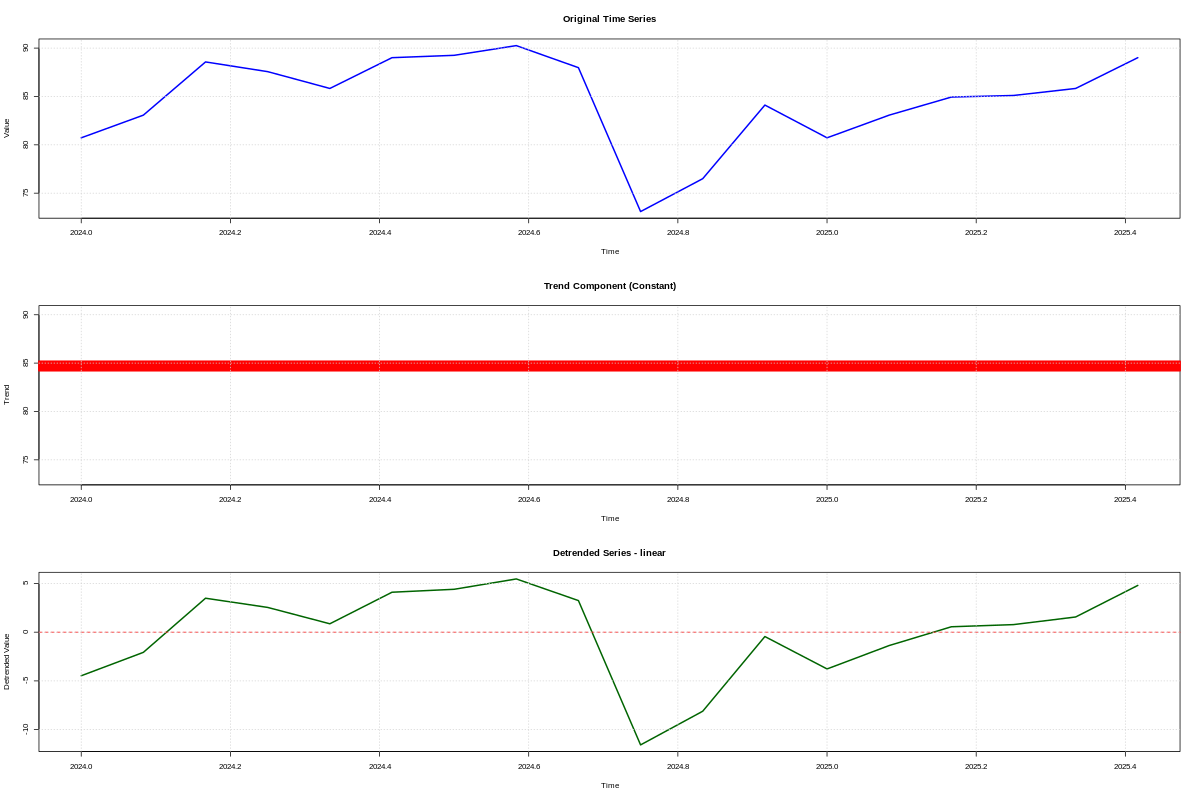

In [ ]:
# Just deseasonalizing
deseas_result <- deseasonalize_ts(rhrr_sl_ts, model = "additive")
plot_deseasonalize(deseas_result)

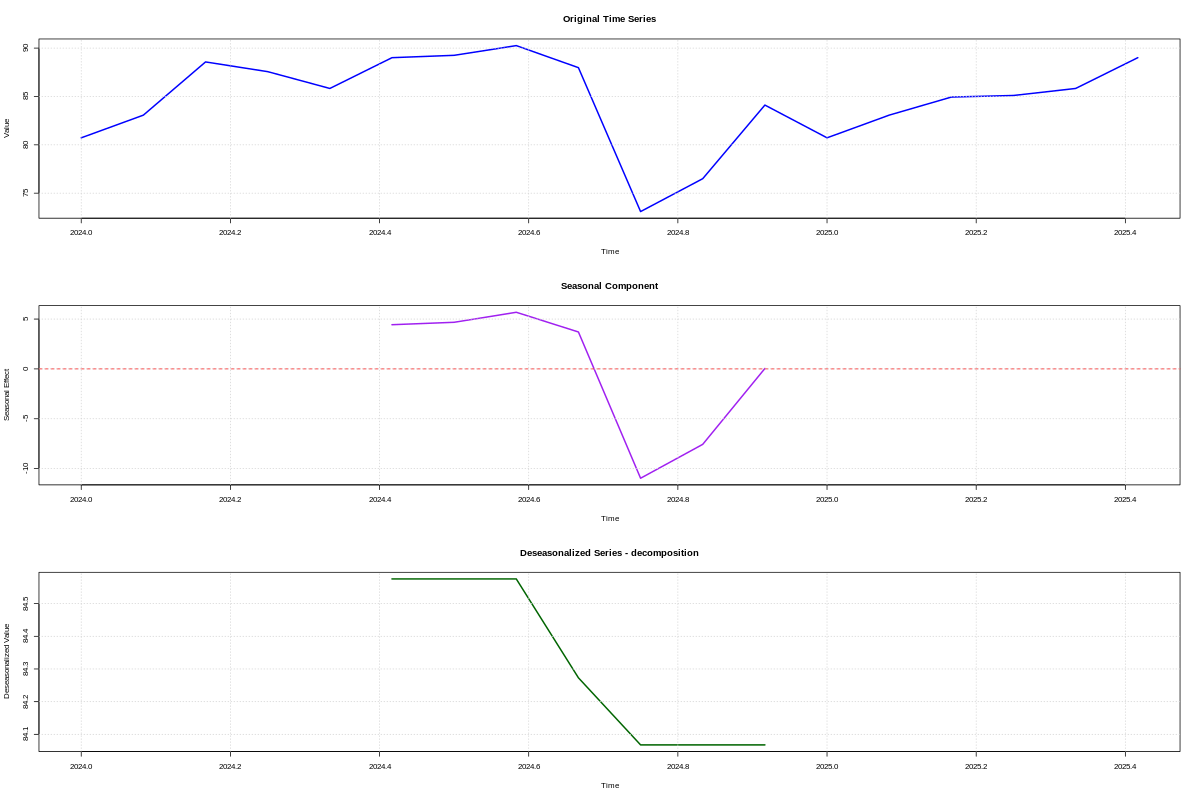

In [179]:
# ============================================================================
# TIME SERIES FORECASTING: 3 MODEL COMPARISON
# Reproductive Health Reporting Rate - Sierra Leone
# ============================================================================

library(forecast)
library(MLmetrics)
library(tidyverse)

# ============================================================================
# 1. SETUP: Prepare Data and Create Training & Validation Datasets
# ============================================================================

# Calculate overall mean reporting rate by month
rhrr_overall <- rhrr_interpolated %>%
  group_by(Date, Year, Month) %>%
  summarise(
    MeanRate = mean(ReportingRate, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Date)

cat("============================================================================\n")
cat("DATASET INFORMATION\n")
cat("============================================================================\n")
cat(sprintf("Total observations: %d months\n", nrow(rhrr_overall)))
cat(sprintf("Period: %s to %s\n",
            min(rhrr_overall$Date),
            max(rhrr_overall$Date)))
cat(sprintf("Districts included: %d\n", length(unique(rhrr_interpolated$District))))

# Create time series object
dataset <- ts(rhrr_overall$MeanRate,
              start = c(min(rhrr_overall$Year), min(rhrr_overall$Month)),
              frequency = 12)

cat(sprintf("\nTime series created: %d observations\n", length(dataset)))
print(dataset)

# Split into Training (first 14 months) and Validation (last 4 months)
n_total <- length(dataset)
n_train <- 14
n_valid <- n_total - n_train

# Get the end point for training
train_end_year <- min(rhrr_overall$Year) + floor((n_train - 1) / 12)
train_end_month <- ((min(rhrr_overall$Month) + n_train - 1 - 1) %% 12) + 1

# Get the start point for validation
valid_start_year <- train_end_year + floor(train_end_month / 12)
valid_start_month <- (train_end_month %% 12) + 1

cat(sprintf("\nSplit: First %d months for training, last %d months for validation\n",
            n_train, n_valid))

# Training dataset
rhrr_train_df <- window(dataset,
                        end = c(train_end_year, train_end_month))

# Validation dataset
rhrr_valid_df <- window(dataset,
                        start = c(valid_start_year, valid_start_month))

cat(sprintf("\nTraining set: %d observations (%.2f years)\n",
            length(rhrr_train_df), length(rhrr_train_df)/12))
cat("Training period:", paste(start(rhrr_train_df), collapse = "-"), "to",
    paste(end(rhrr_train_df), collapse = "-"), "\n")
cat("\nTraining data:\n")
print(rhrr_train_df)

cat(sprintf("\nValidation set: %d observations\n", length(rhrr_valid_df)))
cat("Validation period:", paste(start(rhrr_valid_df), collapse = "-"), "to",
    paste(end(rhrr_valid_df), collapse = "-"), "\n")
cat("\nValidation data:\n")
print(rhrr_valid_df)

# ============================================================================
# 2. MODEL 1: SEASONAL ARIMA
# ============================================================================

cat("\n============================================================================\n")
cat("MODEL 1: SEASONAL ARIMA\n")
cat("============================================================================\n")
cat("⚠️  NOTE: Limited data (14 months training)\n")
cat("   Seasonal ARIMA typically requires 48+ months\n")
cat("   Limiting model complexity to prevent overfitting\n\n")

# Fit Seasonal ARIMA model with constraints
model_sarima <- auto.arima(
  rhrr_train_df,
  seasonal = TRUE,
  stepwise = TRUE,
  approximation = FALSE,
  max.p = 2,  # Limit AR order
  max.q = 2,  # Limit MA order
  max.P = 1,  # Limit seasonal AR order
  max.Q = 1,  # Limit seasonal MA order
  max.d = 1,  # Max differencing
  max.D = 1,  # Max seasonal differencing
  trace = TRUE
)

# Extract model orders
orders <- arimaorder(model_sarima)

cat("\n--- SELECTED MODEL ---\n")
cat(sprintf("ARIMA(%d,%d,%d)(%d,%d,%d)[%d]\n",
            orders[1], orders[2], orders[3],
            orders[4], orders[5], orders[6],
            orders[7]))

cat("\nModel: Seasonal ARIMA\n")
cat(sprintf("Formula: ARIMA(%d,%d,%d)(%d,%d,%d)[12]\n",
            orders[1], orders[2], orders[3],
            orders[4], orders[5], orders[6]))

# Summary statistics
cat("\n--- MODEL SUMMARY ---\n")
print(summary(model_sarima))

# Forecast
forecast_sarima <- forecast(model_sarima, h = length(rhrr_valid_df))

# Calculate performance metrics
cat("\n--- VALIDATION PERFORMANCE ---\n")
sarima_mae <- MAE(forecast_sarima$mean, rhrr_valid_df)
sarima_rmse <- RMSE(forecast_sarima$mean, rhrr_valid_df)
sarima_mape <- MAPE(forecast_sarima$mean, rhrr_valid_df) * 100

cat(sprintf("MAE:  %.3f%%\n", sarima_mae))
cat(sprintf("RMSE: %.3f%%\n", sarima_rmse))
cat(sprintf("MAPE: %.2f%%\n", sarima_mape))

# Store results
sarima_results <- data.frame(
  Period = time(rhrr_valid_df),
  Actual = as.numeric(rhrr_valid_df),
  Forecast = as.numeric(forecast_sarima$mean),
  Lower_80 = as.numeric(forecast_sarima$lower[,1]),
  Upper_80 = as.numeric(forecast_sarima$upper[,1]),
  Lower_95 = as.numeric(forecast_sarima$lower[,2]),
  Upper_95 = as.numeric(forecast_sarima$upper[,2]),
  Error = as.numeric(rhrr_valid_df) - as.numeric(forecast_sarima$mean)
)

cat("\nForecast vs Actual:\n")
print(sarima_results[,c("Period", "Actual", "Forecast", "Error")], digits = 3)

# Residual diagnostics
cat("\n--- RESIDUAL DIAGNOSTICS ---\n")
lb_test <- Box.test(residuals(model_sarima), lag = 10, type = "Ljung-Box")
cat(sprintf("Ljung-Box Test (lag=10):\n"))
cat(sprintf("  Chi-squared: %.3f\n", lb_test$statistic))
cat(sprintf("  P-value: %.4f\n", lb_test$p.value))
if(lb_test$p.value > 0.05) {
  cat("  ✓ Residuals appear random (good fit)\n")
} else {
  cat("  ⚠️  Residuals show autocorrelation\n")
}

# ============================================================================
# 3. MODEL 2: SEASONAL NAIVE
# ============================================================================

cat("\n============================================================================\n")
cat("MODEL 2: SEASONAL NAIVE\n")
cat("============================================================================\n")

# Fit Seasonal Naive model
model_snaive <- snaive(rhrr_train_df,
                       h = length(rhrr_valid_df))

cat("\nModel: Seasonal Naive\n")
cat("Formula: Forecast = Value from same month last year\n")

# Summary statistics
cat("\n--- MODEL SUMMARY ---\n")
print(summary(model_snaive))

# Calculate performance metrics
cat("\n--- VALIDATION PERFORMANCE ---\n")
snaive_mae <- MAE(model_snaive$mean, rhrr_valid_df)
snaive_rmse <- RMSE(model_snaive$mean, rhrr_valid_df)
snaive_mape <- MAPE(model_snaive$mean, rhrr_valid_df) * 100

cat(sprintf("MAE:  %.3f%%\n", snaive_mae))
cat(sprintf("RMSE: %.3f%%\n", snaive_rmse))
cat(sprintf("MAPE: %.2f%%\n", snaive_mape))

# Store results
snaive_results <- data.frame(
  Period = time(rhrr_valid_df),
  Actual = as.numeric(rhrr_valid_df),
  Forecast = as.numeric(model_snaive$mean),
  Lower_80 = as.numeric(model_snaive$lower[,1]),
  Upper_80 = as.numeric(model_snaive$upper[,1]),
  Lower_95 = as.numeric(model_snaive$lower[,2]),
  Upper_95 = as.numeric(model_snaive$upper[,2]),
  Error = as.numeric(rhrr_valid_df) - as.numeric(model_snaive$mean)
)

cat("\nForecast vs Actual:\n")
print(snaive_results[,c("Period", "Actual", "Forecast", "Error")], digits = 3)

# ============================================================================
# 4. MODEL 3: ETS (AUTOMATIC SELECTION)
# ============================================================================

cat("\n============================================================================\n")
cat("MODEL 3: ETS (AUTOMATIC EXPONENTIAL SMOOTHING)\n")
cat("============================================================================\n")

# Fit ETS model (automatic selection)
model_ets <- ets(rhrr_train_df)

# Forecast
forecast_ets <- forecast(model_ets, h = length(rhrr_valid_df))

cat("\nModel: ETS (Automatic Selection)\n")
cat(sprintf("Selected: %s\n", model_ets$method))

# Decode ETS notation
ets_components <- model_ets$components
cat(sprintf("  Error type: %s\n", ets_components[1]))
cat(sprintf("  Trend type: %s\n", ets_components[2]))
cat(sprintf("  Seasonal type: %s\n", ets_components[3]))

# Summary statistics
cat("\n--- MODEL SUMMARY ---\n")
print(summary(model_ets))

# Calculate performance metrics
cat("\n--- VALIDATION PERFORMANCE ---\n")
ets_mae <- MAE(forecast_ets$mean, rhrr_valid_df)
ets_rmse <- RMSE(forecast_ets$mean, rhrr_valid_df)
ets_mape <- MAPE(forecast_ets$mean, rhrr_valid_df) * 100

cat(sprintf("MAE:  %.3f%%\n", ets_mae))
cat(sprintf("RMSE: %.3f%%\n", ets_rmse))
cat(sprintf("MAPE: %.2f%%\n", ets_mape))

# Store results
ets_results <- data.frame(
  Period = time(rhrr_valid_df),
  Actual = as.numeric(rhrr_valid_df),
  Forecast = as.numeric(forecast_ets$mean),
  Lower_80 = as.numeric(forecast_ets$lower[,1]),
  Upper_80 = as.numeric(forecast_ets$upper[,1]),
  Lower_95 = as.numeric(forecast_ets$lower[,2]),
  Upper_95 = as.numeric(forecast_ets$upper[,2]),
  Error = as.numeric(rhrr_valid_df) - as.numeric(forecast_ets$mean)
)

cat("\nForecast vs Actual:\n")
print(ets_results[,c("Period", "Actual", "Forecast", "Error")], digits = 3)

# ============================================================================
# 5. MODEL COMPARISON
# ============================================================================

cat("\n============================================================================\n")
cat("MODEL PERFORMANCE COMPARISON\n")
cat("============================================================================\n")

comparison_df <- data.frame(
  Model = c("Seasonal ARIMA", "Seasonal Naive", "ETS Auto"),
  MAE = c(sarima_mae, snaive_mae, ets_mae),
  RMSE = c(sarima_rmse, snaive_rmse, ets_rmse),
  MAPE = c(sarima_mape, snaive_mape, ets_mape)
)

# Rank by MAE
comparison_df <- comparison_df[order(comparison_df$MAE), ]
comparison_df$Rank <- 1:nrow(comparison_df)

cat("\nRanked by MAE (Lower is better):\n")
print(comparison_df, row.names = FALSE, digits = 3)

# Best model
best_model_name <- comparison_df$Model[1]
best_mae <- comparison_df$MAE[1]

cat(sprintf("\n🏆 BEST MODEL: %s\n", best_model_name))
cat(sprintf("   MAE: %.3f%% | RMSE: %.3f%% | MAPE: %.2f%%\n",
            comparison_df$MAE[1],
            comparison_df$RMSE[1],
            comparison_df$MAPE[1]))

# ============================================================================
# 6. VISUALIZATION: Individual Model Plots
# ============================================================================

cat("\n--- GENERATING PLOTS ---\n")

# Calculate split time for vertical line
split_time <- end(rhrr_train_df)[1] + end(rhrr_train_df)[2]/12

# Plot 1: Seasonal ARIMA
png("model_sarima_forecast.png", width = 1200, height = 600)
plot(dataset,
     col = "black",
     xlab = "Time",
     ylab = "Reporting Rate (%)",
     main = paste("Seasonal ARIMA Forecast -",
                  sprintf("ARIMA(%d,%d,%d)(%d,%d,%d)[12]",
                          orders[1], orders[2], orders[3],
                          orders[4], orders[5], orders[6])),
     type = 'l',
     lwd = 2,
     ylim = c(min(dataset, forecast_sarima$lower[,2], na.rm = TRUE) - 5,
              max(dataset, forecast_sarima$upper[,2], na.rm = TRUE) + 5))

# Add forecasted values
lines(forecast_sarima$mean, col = "blue", lwd = 2)

# Add prediction intervals
polygon(c(time(forecast_sarima$mean), rev(time(forecast_sarima$mean))),
        c(forecast_sarima$lower[,2], rev(forecast_sarima$upper[,2])),
        col = rgb(0.7, 0.7, 0.7, 0.3), border = NA)

polygon(c(time(forecast_sarima$mean), rev(time(forecast_sarima$mean))),
        c(forecast_sarima$lower[,1], rev(forecast_sarima$upper[,1])),
        col = rgb(0.5, 0.5, 0.5, 0.3), border = NA)

# Add vertical line at train/test split
abline(v = split_time, col = "red", lty = 2, lwd = 2)

# Add legend
legend("bottomleft",
       legend = c("Training + Validation Data", "Forecast", "95% PI", "80% PI", "Train/Valid Split"),
       col = c("black", "blue", "gray70", "gray50", "red"),
       lty = c(1, 1, 1, 1, 2),
       lwd = c(2, 2, 10, 10, 2),
       bty = "n")

dev.off()
cat("✓ Seasonal ARIMA plot saved: model_sarima_forecast.png\n")

# Plot 2: Seasonal Naive
png("model_snaive_forecast.png", width = 1200, height = 600)
plot(dataset,
     col = "black",
     xlab = "Time",
     ylab = "Reporting Rate (%)",
     main = "Seasonal Naive Model Forecast",
     type = 'l',
     lwd = 2,
     ylim = c(min(dataset, model_snaive$lower[,2], na.rm = TRUE) - 5,
              max(dataset, model_snaive$upper[,2], na.rm = TRUE) + 5))

lines(model_snaive$mean, col = "darkgreen", lwd = 2)

polygon(c(time(model_snaive$mean), rev(time(model_snaive$mean))),
        c(model_snaive$lower[,2], rev(model_snaive$upper[,2])),
        col = rgb(0.7, 0.7, 0.7, 0.3), border = NA)

polygon(c(time(model_snaive$mean), rev(time(model_snaive$mean))),
        c(model_snaive$lower[,1], rev(model_snaive$upper[,1])),
        col = rgb(0.5, 0.5, 0.5, 0.3), border = NA)

abline(v = split_time, col = "red", lty = 2, lwd = 2)

legend("bottomleft",
       legend = c("Training + Validation Data", "Forecast", "95% PI", "80% PI", "Train/Valid Split"),
       col = c("black", "darkgreen", "gray70", "gray50", "red"),
       lty = c(1, 1, 1, 1, 2),
       lwd = c(2, 2, 10, 10, 2),
       bty = "n")

dev.off()
cat("✓ Seasonal Naive plot saved: model_snaive_forecast.png\n")

# Plot 3: ETS
png("model_ets_forecast.png", width = 1200, height = 600)
plot(dataset,
     col = "black",
     xlab = "Time",
     ylab = "Reporting Rate (%)",
     main = paste("ETS Model Forecast -", model_ets$method),
     type = 'l',
     lwd = 2,
     ylim = c(min(dataset, forecast_ets$lower[,2], na.rm = TRUE) - 5,
              max(dataset, forecast_ets$upper[,2], na.rm = TRUE) + 5))

lines(forecast_ets$mean, col = "purple", lwd = 2)

polygon(c(time(forecast_ets$mean), rev(time(forecast_ets$mean))),
        c(forecast_ets$lower[,2], rev(forecast_ets$upper[,2])),
        col = rgb(0.7, 0.7, 0.7, 0.3), border = NA)

polygon(c(time(forecast_ets$mean), rev(time(forecast_ets$mean))),
        c(forecast_ets$lower[,1], rev(forecast_ets$upper[,1])),
        col = rgb(0.5, 0.5, 0.5, 0.3), border = NA)

abline(v = split_time, col = "red", lty = 2, lwd = 2)

legend("bottomleft",
       legend = c("Training + Validation Data", "Forecast", "95% PI", "80% PI", "Train/Valid Split"),
       col = c("black", "purple", "gray70", "gray50", "red"),
       lty = c(1, 1, 1, 1, 2),
       lwd = c(2, 2, 10, 10, 2),
       bty = "n")

dev.off()
cat("✓ ETS plot saved: model_ets_forecast.png\n")

# ============================================================================
# 7. VISUALIZATION: Comparison Plot (All 3 Models)
# ============================================================================

png("model_comparison_all.png", width = 1400, height = 800)
plot(dataset,
     col = "black",
     xlab = "Time",
     ylab = "Reporting Rate (%)",
     main = "Model Comparison: All Three Forecasts",
     type = 'l',
     lwd = 2)

# Add all three forecasts
lines(forecast_sarima$mean, col = "blue", lwd = 2, lty = 1)
lines(model_snaive$mean, col = "darkgreen", lwd = 2, lty = 2)
lines(forecast_ets$mean, col = "purple", lwd = 2, lty = 3)

# Add validation split line
abline(v = split_time, col = "red", lty = 2, lwd = 2)

# Add legend
legend("bottomleft",
       legend = c("Historical Data", "Train/Test Split",
                  sprintf("SARIMA (MAE=%.2f)", sarima_mae),
                  sprintf("Seasonal Naive (MAE=%.2f)", snaive_mae),
                  sprintf("ETS (MAE=%.2f)", ets_mae)),
       col = c("black", "red", "blue", "darkgreen", "purple"),
       lty = c(1, 2, 1, 2, 3),
       lwd = c(2, 2, 2, 2, 2),
       bty = "n")

dev.off()
cat("✓ Comparison plot saved: model_comparison_all.png\n")

# ============================================================================
# 8. SAVE RESULTS
# ============================================================================

# Save comparison table
write.csv(comparison_df, "model_comparison_metrics.csv", row.names = FALSE)
cat("\n✓ Comparison metrics saved: model_comparison_metrics.csv\n")

# Save detailed forecast results
write.csv(sarima_results, "sarima_forecast_results.csv", row.names = FALSE)
write.csv(snaive_results, "snaive_forecast_results.csv", row.names = FALSE)
write.csv(ets_results, "ets_forecast_results.csv", row.names = FALSE)
cat("✓ Detailed forecast results saved\n")

cat("\n============================================================================\n")
cat("ANALYSIS COMPLETE\n")
cat("============================================================================\n")
cat(sprintf("\nBest performing model: %s\n", best_model_name))
cat(sprintf("Validation MAE: %.3f%%\n", best_mae))
cat(sprintf("\n⚠️  REMINDER: Limited training data (14 months)\n"))
cat("   Results should be interpreted with caution\n")
cat("   Seasonal patterns based on incomplete cycles\n")

DATASET INFORMATION
Total observations: 18 months
Period: 2024-01-01 to 2025-06-01
Districts included: 13

Time series created: 18 observations
          Jan      Feb      Mar      Apr      May      Jun      Jul      Aug
2024 80.72462 83.07000 88.56846 87.56462 85.82692 89.00846 89.25231 90.25692
2025 80.72462 83.07000 84.93769 85.10154 85.82692 89.00846                  
          Sep      Oct      Nov      Dec
2024 87.97538 73.10038 76.50038 84.10888
2025                                    

Split: First 14 months for training, last 4 months for validation

Training set: 14 observations (1.17 years)
Training period: 2024-1 to 2025-2 

Training data:
          Jan      Feb      Mar      Apr      May      Jun      Jul      Aug
2024 80.72462 83.07000 88.56846 87.56462 85.82692 89.00846 89.25231 90.25692
2025 80.72462 83.07000                                                      
          Sep      Oct      Nov      Dec
2024 87.97538 73.10038 76.50038 84.10888
2025                       

agg_record_1795482899 
                    2

✓ Seasonal ARIMA plot saved: model_sarima_forecast.png


agg_record_1795482899 
                    2

✓ Seasonal Naive plot saved: model_snaive_forecast.png


agg_record_1795482899 
                    2

✓ ETS plot saved: model_ets_forecast.png


agg_record_1795482899 
                    2

✓ Comparison plot saved: model_comparison_all.png

✓ Comparison metrics saved: model_comparison_metrics.csv
✓ Detailed forecast results saved

ANALYSIS COMPLETE

Best performing model: Seasonal Naive
Validation MAE: 1.523%

⚠️  REMINDER: Limited training data (14 months)
   Results should be interpreted with caution
   Seasonal patterns based on incomplete cycles
